In [13]:
!pip install ultralytics


Apply object tracking on attached video using three different

versions of the YOLO model — YOLOv10n, YOLOv11n, and YOLOv12n — and compare their inference speed. You will evaluate each model using the same video.

**Submission Requirements:**

1- Report with an inference speed comparison of the three models.

2- Jupyter notebook showing each model’s result (predicted video).

In [9]:
from ultralytics import YOLO
import cv2
import numpy as np
import os
import kagglehub
from google.colab import files
import matplotlib.pyplot as plt


In [14]:
path = kagglehub.dataset_download("bosyayman202202076/video-yolo")
print("Files in dataset folder:", os.listdir(path))

# Define the input video path
video_path = os.path.join(path, 'test1.mp4')


Files in dataset folder: ['test1.mp4']


In [19]:
model_paths = {
   'YOLOv10n': YOLO('yolov10n.pt'),
    'YOLOv11n': YOLO("yolo11n.pt"),
    'YOLOv12n': YOLO('yolo12n.pt')
}


In [20]:
inference_speeds = {name: [] for name in models.keys()}

In [21]:
def convert_avi_to_mp4(avi_path, mp4_path):
    cap = cv2.VideoCapture(avi_path)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(mp4_path, fourcc, fps, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)

    cap.release()
    out.release()
    return mp4_path


In [22]:
tracked_videos = {}

for model_name, model in models.items():
    print(f'Running tracking with {model_name}...')

    # Run object tracking
    results = model.track(
        source=video_path,
        show=False,
        save=True,
        persist=True,
        conf=0.25,
        iou=0.7,
        stream=True
    )

    # Store inference speed
    for r in results:
        inference_speeds[model_name].append(r.speed['inference'])

    # Convert AVI to MP4
    save_dir = r.save_dir  
    avi_path = os.path.join(save_dir, 'test1.avi')
    mp4_path = os.path.join(save_dir, f'test1_{model_name.lower()}_tracked.mp4')
    convert_avi_to_mp4(avi_path, mp4_path)

    tracked_videos[model_name] = mp4_path
    print(f'{model_name} result saved at {mp4_path}')


Running tracking with YOLOv10n...

video 1/1 (frame 1/942) /kaggle/input/video-yolo/test1.mp4: 384x640 1 car, 130.4ms
video 1/1 (frame 2/942) /kaggle/input/video-yolo/test1.mp4: 384x640 4 cars, 1 train, 1 truck, 105.6ms
video 1/1 (frame 3/942) /kaggle/input/video-yolo/test1.mp4: 384x640 4 cars, 1 train, 1 truck, 98.7ms
video 1/1 (frame 4/942) /kaggle/input/video-yolo/test1.mp4: 384x640 5 cars, 1 train, 1 truck, 94.0ms
video 1/1 (frame 5/942) /kaggle/input/video-yolo/test1.mp4: 384x640 4 cars, 1 train, 2 trucks, 94.7ms
video 1/1 (frame 6/942) /kaggle/input/video-yolo/test1.mp4: 384x640 5 cars, 1 train, 2 trucks, 87.7ms
video 1/1 (frame 7/942) /kaggle/input/video-yolo/test1.mp4: 384x640 5 cars, 1 bus, 1 train, 2 trucks, 96.7ms
video 1/1 (frame 8/942) /kaggle/input/video-yolo/test1.mp4: 384x640 7 cars, 1 bus, 1 train, 2 trucks, 93.1ms
video 1/1 (frame 9/942) /kaggle/input/video-yolo/test1.mp4: 384x640 6 cars, 1 bus, 1 train, 3 trucks, 127.6ms
video 1/1 (frame 10/942) /kaggle/input/video-y

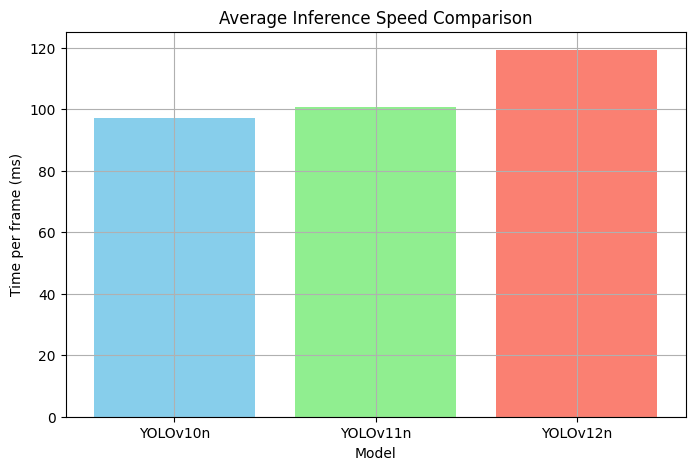

YOLOv10n: 97.09 ms/frame
YOLOv11n: 100.54 ms/frame
YOLOv12n: 119.19 ms/frame


In [25]:
avg_speeds = {name: np.mean(speeds) for name, speeds in inference_speeds.items()}

# Display results in a bar chart
plt.figure(figsize=(8, 5))
plt.bar(avg_speeds.keys(), avg_speeds.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Average Inference Speed Comparison')
plt.ylabel('Time per frame (ms)')
plt.xlabel('Model')
plt.grid(True)
plt.show()

# Display numerical results
for name, speed in avg_speeds.items():
    print(f"{name}: {speed:.2f} ms/frame")


# YOLOv10n demonstrated the fastest average inference speed, making it more suitable for real time applications compared to YOLOv12n.